### Compare the form stress in the 1-layer and 2-layer best tuned case

In [1]:
%matplotlib inline

import datetime, time
import numpy as np
import xesmf as xe
import xarray as xr
import netCDF4 as nc
import cmocean as cm
import matplotlib.ticker
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from scipy.optimize import curve_fit
from matplotlib.colors import LogNorm

import warnings
warnings.filterwarnings('ignore')

In [2]:
bt = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_x05/output003/ocean_interior.nc')
bc = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_x02/output009/ocean_interior.nc')
gd = xr.open_dataset('/scratch/nm03/lxy581/mom6/archive/tides_008_global_sigma_SAL_2layer_x02/output009/ocean_static.nc')

In [3]:
stress_x_bt = bt.form_stress_x # all zero
stress_y_bt = bt.form_stress_y # all zero

stress_x_bc = bc.form_stress_x
stress_y_bc = bc.form_stress_y

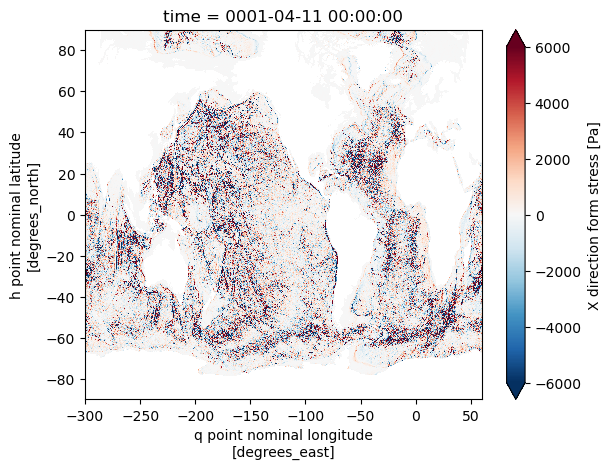

In [4]:
stress_x_bc.isel(time=-1).plot(vmin=-6e+3,vmax=6e+3,cmap="RdBu_r")

In [5]:
stress_x_bc.isel(time=-1).shape

(3270, 4321)

#### Compute the cumulative integral along x

In [6]:
# compute dx 
R = 6371e+3  # meters
dlon = np.deg2rad(gd.xh[1].values-gd.xh[0].values)
dx = R * np.cos(np.deg2rad(gd.geolat_u)) * dlon

In [7]:
cum_int = (stress_x_bc.isel(time=-1) * dx).fillna(0).cumsum(dim='xq')

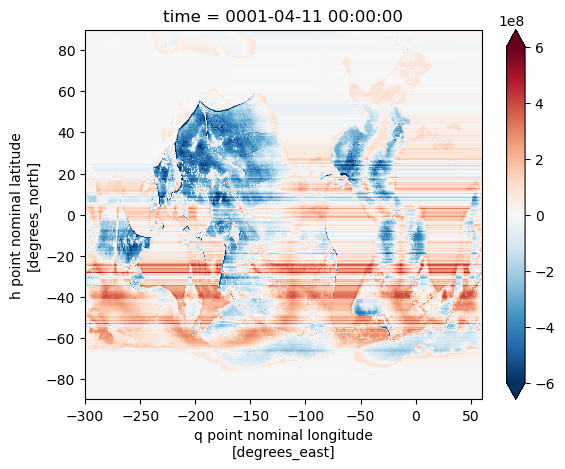

In [8]:
cum_int.plot(vmin=-6e+8,vmax=6e+8,cmap="RdBu_r",extend='both')

#### Sample the form stress across a constant depth range

In [9]:
depth = gd.deptho

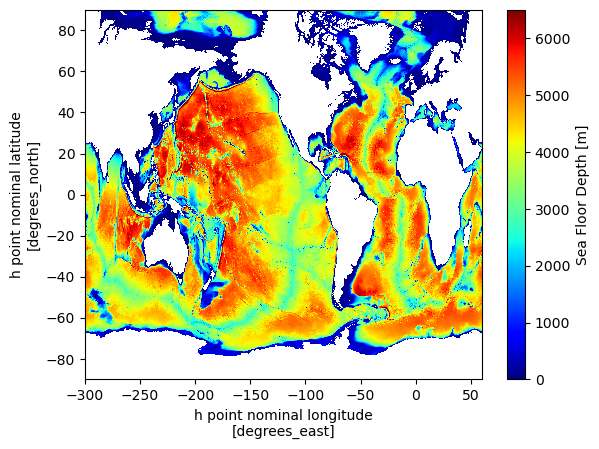

In [10]:
depth.plot(vmin=0,vmax=6500,cmap="jet")

In [11]:
mask_depth = (depth > 3000) & (depth < 3500)

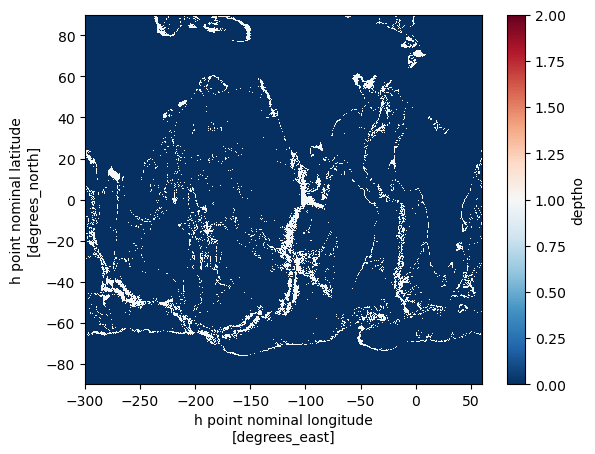

In [12]:
mask_depth.plot(vmin=0,vmax=2,cmap="RdBu_r")

#### Interpolate stress from u-points to h-points

In [13]:
weights_base = Path("/g/data/nm03/lxy581/archive/tides_008_global_sigma_x06/output002/")
weights_u = weights_base / "u2h_weights.nc"
weights_v = weights_base / "v2h_weights.nc"

In [14]:
def interp_u2h(var, weights_u):
    ds_u = xr.Dataset(data_vars={'dissip': (('yh','xq'), np.array(var)),
                                },
                      coords={'lon': (('yh', 'xq'), np.array(gd.geolon_u)),
                              'lat': (('yh', 'xq'), np.array(gd.geolat_u))})
    ds_h = xr.Dataset(data_vars={"lat": (('yh', 'xh'), np.array(gd.geolat)),
                                 "lon": (('yh', 'xh'), np.array(gd.geolon)),
                                 },
                      coords={"yh":np.array(gd.yh), "xh":np.array(gd.xh)})
    regridder_u2h = xe.Regridder(ds_u, ds_h, "bilinear", extrap_method="inverse_dist", reuse_weights=True, weights=
                                 weights_u)
    ds_h = regridder_u2h(ds_u)
    return ds_h['dissip']

In [15]:
def interp_v2h(var, weights_v):
    ds_v = xr.Dataset(data_vars={'dissip': (('yq','xh'), np.array(var)),
                                },
                      coords={'lon': (('yq', 'xh'), np.array(gd.geolon_v)),
                              'lat': (('yq', 'xh'), np.array(gd.geolat_v))})
    ds_h = xr.Dataset(data_vars={"lat": (('yh', 'xh'), np.array(gd.geolat)),
                                 "lon": (('yh', 'xh'), np.array(gd.geolon)),
                                 },
                      coords={"yh":np.array(gd.yh), "xh":np.array(gd.xh)})
    regridder_v2h = xe.Regridder(ds_v, ds_h, "bilinear", extrap_method="inverse_dist", reuse_weights=True, weights=
                                 weights_v)
    ds_h = regridder_v2h(ds_v)
    return ds_h['dissip']

In [16]:
stress_x_sample = stress_x_bc.isel(time=-1)
stress_y_sample = stress_y_bc.isel(time=-1)

In [17]:
stress_u2h = interp_u2h(stress_x_sample, weights_u)
stress_v2h = interp_v2h(stress_y_sample, weights_v)

In [18]:
# cut across constant depth
stress_x_cut = stress_u2h * mask_depth
stress_y_cut = stress_v2h * mask_depth

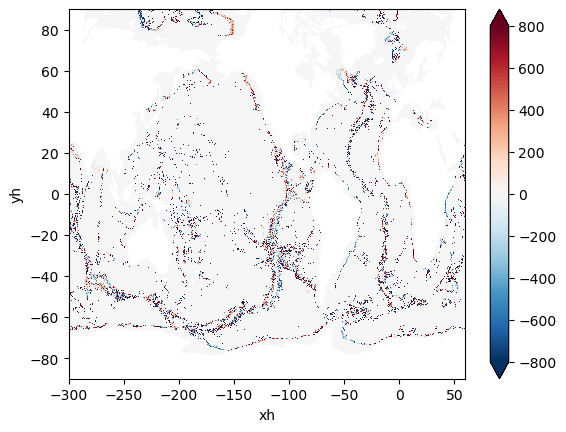

In [19]:
stress_x_cut.plot(vmin=-8e+2,vmax=8e+2,cmap="RdBu_r")